# 04 — Sensitivity to Rashomon size K

**Purpose:** Test sensitivity to K (Rashomon size). Vary K ∈ {5, 10, 15, 20, 25, 30, 35, 40, 45, 50}, compute multiplicity and spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_figure_dir

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_meta, run_multiplicity, run_spatial

FIG_DIR = thesis_figure_dir("nb04")

RESULTS_DIR = RAW_RESULTS

## Loop over K and store results

In [2]:
K_LIST = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
k_nn = 30

SUPPORTED_DATASETS = ("compas", "german", "adult")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]

def run_one_k(run_dir, X_test, K):
    n_cand = len(load_meta(run_dir))
    if K > n_cand:
        return None
    K_actual = min(K, n_cand)
    mult = run_multiplicity(run_dir, K=K_actual)
    spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
    return {
        "mean_variance": mult["mean_variance"],
        "mean_conflict": mult["mean_conflict"],
        "moran_i": spatial["moran_i"],
        "n_hh": int(np.sum(spatial["HH_mask"])),
        "conflict_moran_i": spatial.get("conflict_moran_i", np.nan),
        "conflict_n_hh": spatial.get("conflict_n_hh", 0),
        "HH_mask": spatial["HH_mask"],
        "n_candidates": n_cand,
        "K_actual": K_actual,
    }

results_k = []
hh_masks_by_run = {}  # (dataset, seed_name) -> {K: HH_mask}
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    for K in K_LIST:
        for run_dir in run_dirs:
            X_test = get_transformed_test_features(run_dir, dataset_name)
            res = run_one_k(run_dir, X_test, K)
            if res is not None:
                hh_mask = res.pop("HH_mask")
                key = (dataset_name, run_dir.name)
                if key not in hh_masks_by_run:
                    hh_masks_by_run[key] = {}
                hh_masks_by_run[key][K] = hh_mask
                results_k.append({"dataset": dataset_name, "seed": run_dir.name, "K": K, **res})

df_k = pd.DataFrame(results_k)
print(df_k.groupby(["dataset", "K"]).agg({
    "mean_variance": ["mean", "std"], "mean_conflict": ["mean", "std"],
    "moran_i": ["mean", "std"], "n_hh": "mean",
    "conflict_moran_i": ["mean", "std"], "conflict_n_hh": "mean",
}).round(4))

C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


...

C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


           mean_variance         mean_conflict         moran_i           n_hh  \
                    mean     std          mean     std    mean     std   mean   
dataset K                                                                       
adult   5         0.0006  0.0001        0.0102  0.0010  0.0341  0.0148   59.6   
        10        0.0009  0.0001        0.0132  0.0009  0.0499  0.0173   84.8   
        15        0.0010  0.0001        0.0146  0.0009  0.0631  0.0193  115.3   
        20        0.0012  0.0002        0.0157  0.0012  0.0717  0.0210  145.5   
        25        0.0014  0.0001        0.0172  0.0011  0.0813  0.0237  184.1   
        30        0.0016  0.0001        0.0186  0.0011  0.0937  0.0239  249.6   
        35        0.0018  0.0002        0.0203  0.0015  0.1121  0.0275  338.1   
        40        0.0022  0.0002        0.0224  0.0013  0.1358  0.0287  444.6   
        45        0.0024  0.0002        0.0237  0.0013  0.1584  0.0267  525.8   
        50        0.0025  0.

## Elbow / stabilization curves

Mean ± std bands over seeds for variance-based and conflict-based metrics across K.

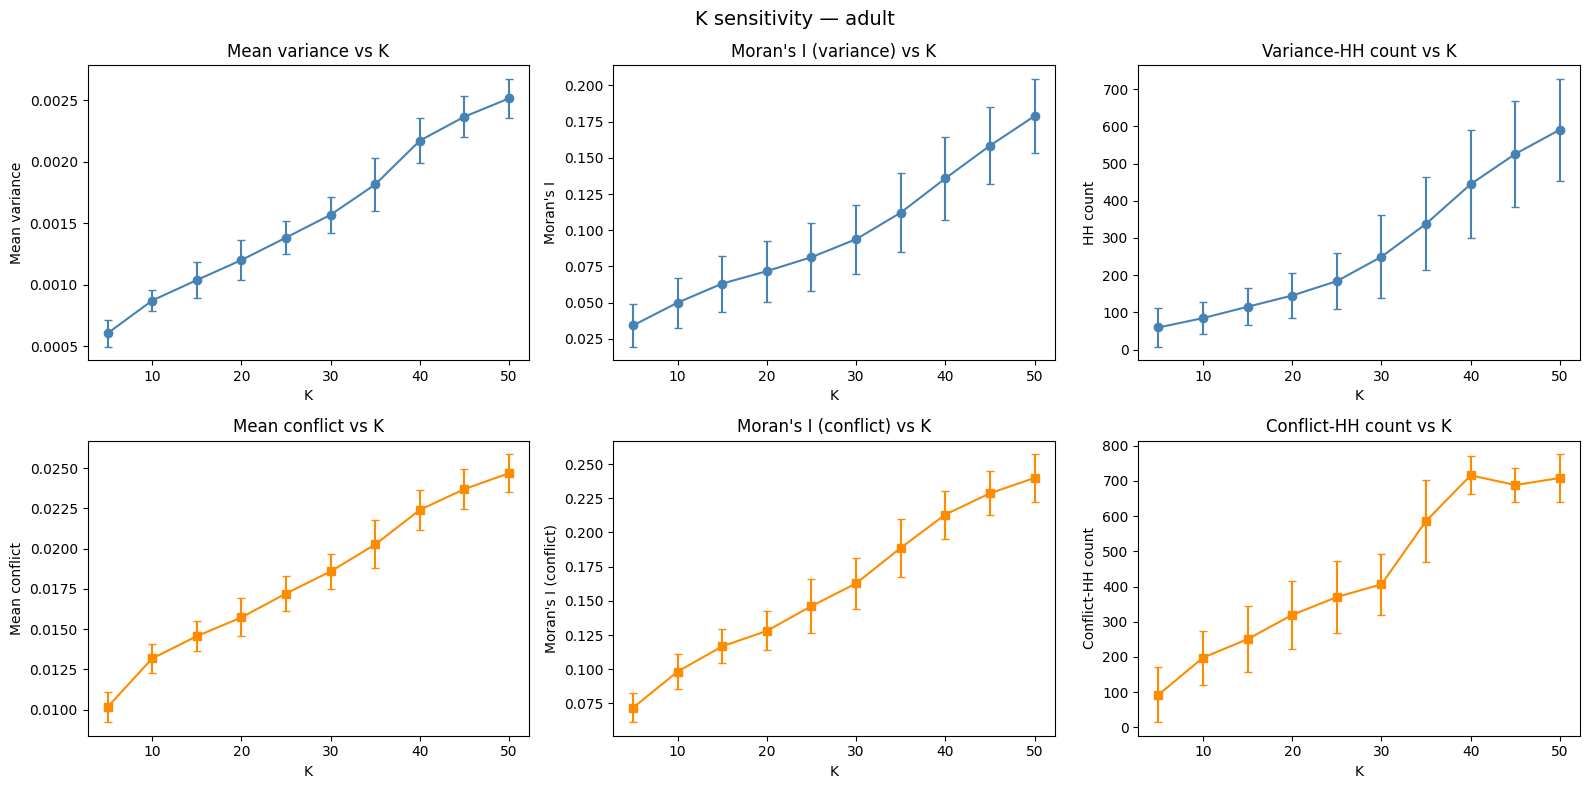

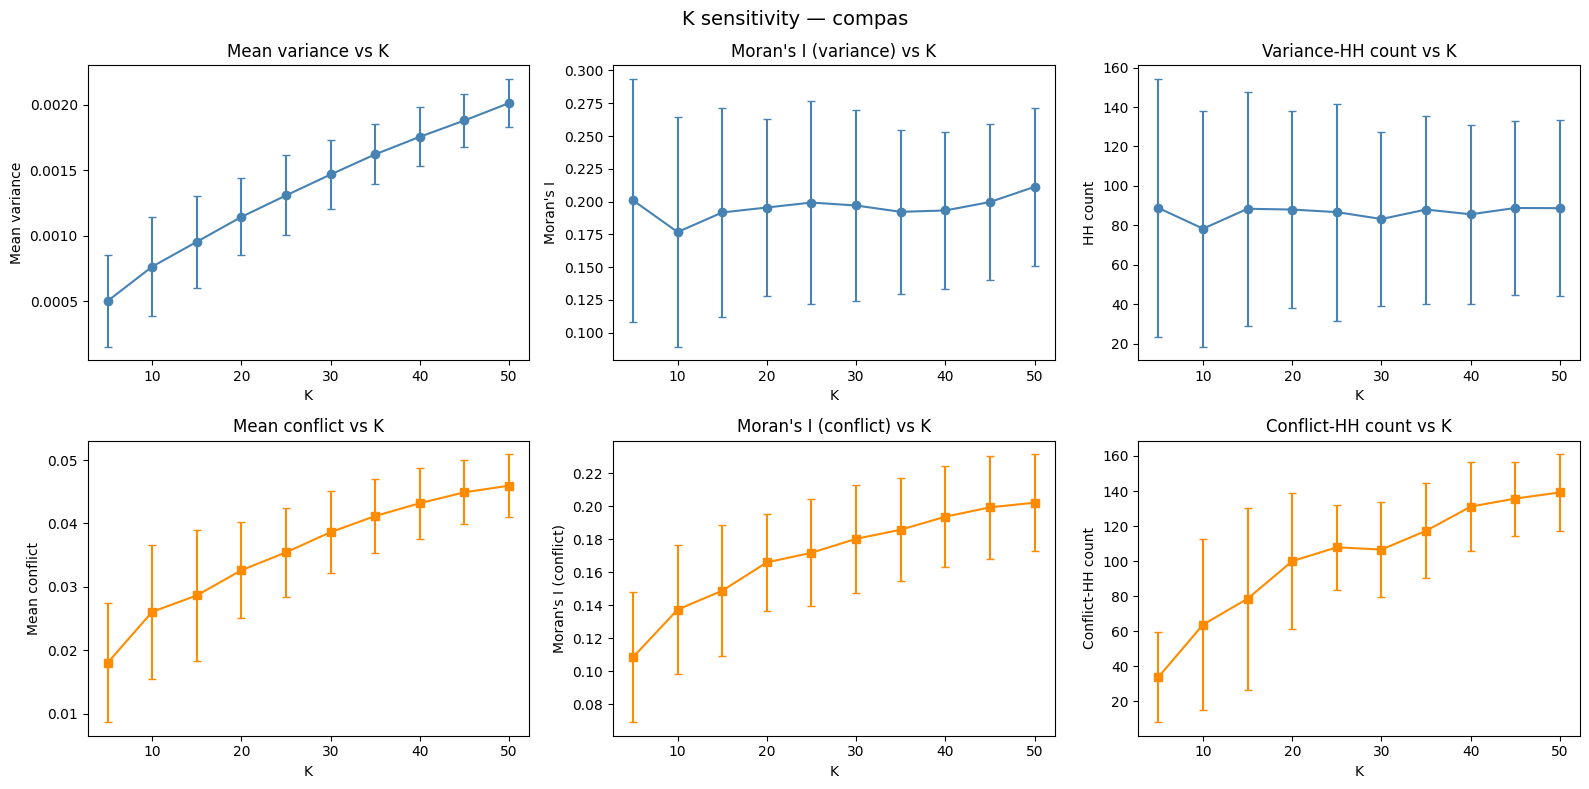

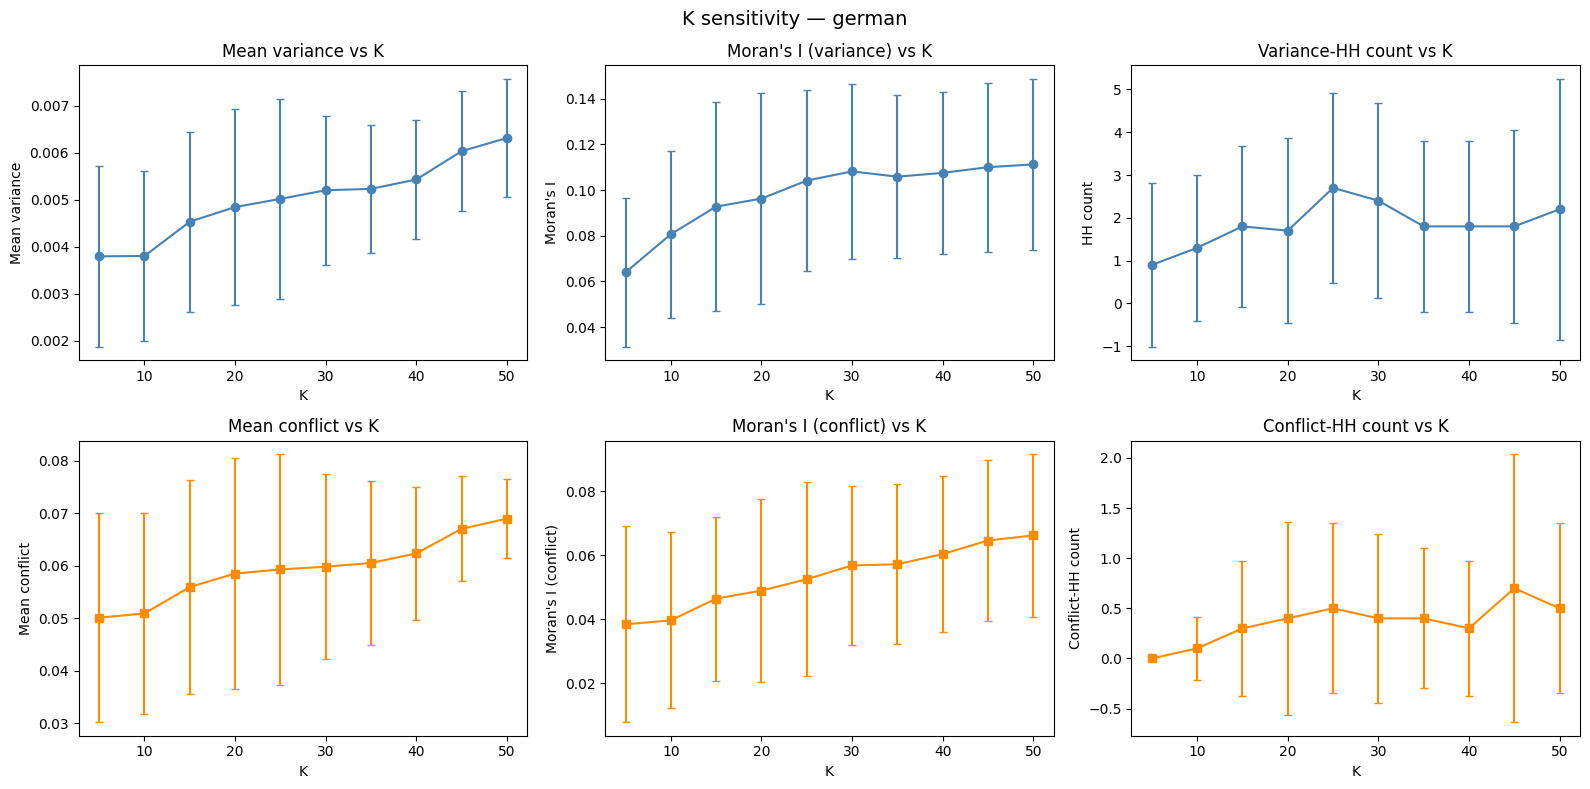

In [3]:
agg_k = df_k.groupby(["dataset", "K"]).agg(
    mean_variance_mean=("mean_variance", "mean"), mean_variance_std=("mean_variance", "std"),
    mean_conflict_mean=("mean_conflict", "mean"), mean_conflict_std=("mean_conflict", "std"),
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
    conflict_moran_mean=("conflict_moran_i", "mean"), conflict_moran_std=("conflict_moran_i", "std"),
    conflict_n_hh_mean=("conflict_n_hh", "mean"), conflict_n_hh_std=("conflict_n_hh", "std"),
).reset_index()

for ds_name, ds_agg in agg_k.groupby("dataset"):
    d = ds_agg
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    axes[0, 0].errorbar(d["K"], d["mean_variance_mean"], yerr=d["mean_variance_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 0].set_xlabel("K"); axes[0, 0].set_ylabel("Mean variance"); axes[0, 0].set_title("Mean variance vs K")

    axes[0, 1].errorbar(d["K"], d["moran_mean"], yerr=d["moran_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 1].set_xlabel("K"); axes[0, 1].set_ylabel("Moran's I"); axes[0, 1].set_title("Moran's I (variance) vs K")

    axes[0, 2].errorbar(d["K"], d["n_hh_mean"], yerr=d["n_hh_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 2].set_xlabel("K"); axes[0, 2].set_ylabel("HH count"); axes[0, 2].set_title("Variance-HH count vs K")

    axes[1, 0].errorbar(d["K"], d["mean_conflict_mean"], yerr=d["mean_conflict_std"], marker="s", capsize=3, color="darkorange")
    axes[1, 0].set_xlabel("K"); axes[1, 0].set_ylabel("Mean conflict"); axes[1, 0].set_title("Mean conflict vs K")

    axes[1, 1].errorbar(d["K"], d["conflict_moran_mean"], yerr=d["conflict_moran_std"], marker="s", capsize=3, color="darkorange")
    axes[1, 1].set_xlabel("K"); axes[1, 1].set_ylabel("Moran's I (conflict)"); axes[1, 1].set_title("Moran's I (conflict) vs K")

    axes[1, 2].errorbar(d["K"], d["conflict_n_hh_mean"], yerr=d["conflict_n_hh_std"], marker="s", capsize=3, color="darkorange")
    axes[1, 2].set_xlabel("K"); axes[1, 2].set_ylabel("Conflict-HH count"); axes[1, 2].set_title("Conflict-HH count vs K")

    fig.suptitle(f"K sensitivity — {ds_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_K_curves_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## Diagnostic: candidate pool size

Report the number of candidates (n_candidates) per run to check whether K_actual = min(K, n_candidates) truncates any K value.

In [4]:
diag = df_k.groupby(["dataset", "seed"]).agg(
    n_candidates=("n_candidates", "first"),
    max_K_actual=("K_actual", "max"),
    n_K_values_computed=("K_actual", "count"),
).reset_index()
print("Candidate pool diagnostic:")
print(diag.to_string(index=False))
print()
for ds in diag["dataset"].unique():
    sub = diag[diag["dataset"] == ds]
    min_cand = sub["n_candidates"].min()
    print(f"  {ds}: min n_candidates = {min_cand}, max K in K_LIST = {max(K_LIST)}", end="")
    if min_cand < max(K_LIST):
        print(f"  ⚠ K truncated at {min_cand} for some runs")
    else:
        print("  ✓ all K values feasible")

Candidate pool diagnostic:
dataset   seed  n_candidates  max_K_actual  n_K_values_computed
  adult seed=0           250            50                   10
  adult seed=1           250            50                   10
  adult seed=2           250            50                   10
  adult seed=3           250            50                   10
  adult seed=4           250            50                   10
  adult seed=5           250            50                   10
  adult seed=6           250            50                   10
  adult seed=7           250            50                   10
  adult seed=8           250            50                   10
  adult seed=9           250            50                   10
 compas seed=0           250            50                   10
 compas seed=1           250            50                   10
 compas seed=2           250            50                   10
 compas seed=3           250            50                   10
 compas seed=

## Interpret stability

If mean variance and Moran's I stabilize (flat or elbow) as K increases, the chosen K is not driving artifacts.